# L4b Advanced: Drift Uncertainty

The L4b lecture said that the drift is the harder of the two GBM parameters to estimate, and the companion example computed a regression confidence interval for the mean growth rate that was suspiciously narrow. This notebook makes both statements precise. Under GBM the sample mean of the growth rates telescopes to the total log price change over the sample, so its standard error depends only on the calendar span of the data and not at all on how finely the data are sampled; the volatility, by contrast, sharpens with every additional observation. We work out what that means for how many years of data it takes to pin down a drift, and then propagate the honest drift uncertainty through the closed-form target probability of the lecture.

> __Learning Objectives:__
>
> By the end of this example, you should be able to:
> - **Derive the span rule for the drift:** Show that the sample-mean estimate of the mean growth rate depends only on the first and last prices, so its standard error is the volatility divided by the square root of the calendar span, whatever the sampling frequency.
> - **Contrast drift with volatility:** Confirm by simulation that finer sampling sharpens the volatility estimate but leaves the drift estimate exactly as uncertain, and quantify how many years of data a given drift precision requires.
> - **Propagate drift uncertainty into a decision:** Turn the interval for the mean growth rate into a band on the probability that a scheduled trade clears its target, and compare it with the much smaller effect of volatility uncertainty.

Let's get started!
___

## Setup, Data, and Prerequisites

We simulate constant-parameter GBM growth-rate series with the exact one-step transition of the lecture and study the sampling distributions of the parameter estimates. The local `Include.jl` file activates the course project and loads the required packages.

> The [`include(...)` command](https://docs.julialang.org/en/v1/base/base/#include) evaluates the contents of the input source file, `Include.jl`, in the notebook's global scope. The `Include.jl` file sets paths, loads required external packages, etc. For additional information on functions and types used in this material, see the [Julia programming language documentation](https://docs.julialang.org/en/v1/).

Let's set up our code environment:

In [1]:
include(joinpath(@__DIR__, "Include.jl")); # include the Include.jl file

  Activating project at `~/Desktop/julia_work/CHEME-5660-CourseRepository-Fall-2026`


The `Include.jl` file activates the course project and loads [the `DataFrames.jl` package](https://dataframes.juliadata.org/stable/) for tabular results, [the `Distributions.jl` package](https://juliastats.org/Distributions.jl/stable/) for the normal distribution, [the `Plots.jl` package](https://docs.juliaplots.org/stable/) for figures, [the `PrettyTables.jl` package](https://ronisbr.github.io/PrettyTables.jl/stable/) for tables, and the `Random` and `Statistics` standard libraries for the simulations. This notebook defines its own functions, so no local source files are loaded. Let's set the plotting defaults:

In [2]:
default(
    fontfamily = "Helvetica",
    framestyle = :box,
    background_color = :gray97,
    background_color_outside = :white,
    legend_background_color = nothing,
    linewidth = 2,
);

___

## 1. The drift estimate depends on the span, not the sampling frequency

Take $N+1$ prices on the grid $t_{j}=j\Delta t$, spanning $T_{\text{span}}=N\Delta t$ years, and form the one-step growth rates $g_{j}=(1/\Delta t)\ln(S_{t_{j}}/S_{t_{j-1}})$. Method 1 of the lecture estimates the mean growth rate $\bar g=\mu-\sigma^{2}/2$ by the sample mean, and that sample mean telescopes:
$$
\widehat{\bar g}=\frac{1}{N}\sum_{j=1}^{N}g_{j}=\frac{1}{N\Delta t}\sum_{j=1}^{N}\ln\frac{S_{t_{j}}}{S_{t_{j-1}}}=\frac{1}{T_{\text{span}}}\ln\frac{S_{T_{\text{span}}}}{S_{0}}.
$$
Only the first and last prices survive. Under GBM, $\ln(S_{T_{\text{span}}}/S_{0})$ is normal with mean $\bar g\,T_{\text{span}}$ and variance $\sigma^{2}T_{\text{span}}$, so
$$
\widehat{\bar g}\sim\mathcal{N}\!\left(\bar g,\;\frac{\sigma^{2}}{T_{\text{span}}}\right),\qquad\text{i.e.}\qquad\mathrm{SE}(\widehat{\bar g})=\frac{\sigma}{\sqrt{T_{\text{span}}}}.
$$
The step $\Delta t$ has disappeared. Sampling the same ten years daily instead of monthly adds thousands of observations and does nothing for the drift, because all of them cancel except the endpoints. The volatility estimate behaves differently: $\hat\sigma=\sigma_{g}\sqrt{\Delta t}$ is built from the sample standard deviation of $N$ independent normal growth rates, and its standard error is approximately $\sigma/\sqrt{2N}$, which does shrink with finer sampling. Robert Merton pointed this out in 1980, and it is the reason drift estimates in this course come with wide error bars.

Let's check both claims by simulation. We fix the true parameters (typical of the S&P 500 estimates in the L4b example) and a span of eleven years, then sample the same kind of path daily, weekly, and monthly, estimating $\bar g$ and $\sigma$ from each; repeating this many times gives the sampling distribution of each estimator:

In [3]:
ḡ_true = 0.10        # true mean growth rate ḡ = μ - σ²/2 (1/years)
σ_true = 0.30        # true volatility (1/sqrt(years))
T_span = 11.0        # calendar span of the sample (years), as in the 2014-2024 dataset
number_of_replicates = 4000

sampling_schemes = (daily = 1/252, weekly = 1/52, monthly = 1/12) # Δt for each scheme (years)
(ḡ_true = ḡ_true, σ_true = σ_true, T_span = T_span, replicates = number_of_replicates)

(ḡ_true = 0.1, σ_true = 0.3, T_span = 11.0, replicates = 4000)

Now let's write the simulation. For each replicate we draw $N$ independent one-step growth rates $g_{j}=\bar g+(\sigma/\sqrt{\Delta t})Z_{j}$ (the growth-rate law from the lecture, which is exactly what the exact one-step transition produces), estimate $\widehat{\bar g}$ by the sample mean and $\hat\sigma$ by the sample standard deviation times $\sqrt{\Delta t}$, and record both. We store the results per scheme in the `sampling_results::Dict{Symbol,NamedTuple}` variable:

In [4]:
function estimate_replicates(ḡ::Real, σ::Real, T_span::Real, Δt::Real, R::Int; seed::Int = 5660)
    rng = MersenneTwister(seed)
    N = round(Int, T_span/Δt)
    ḡ_hat = zeros(Float64, R); σ_hat = zeros(Float64, R)
    g = zeros(Float64, N)
    for r ∈ 1:R
        for j ∈ 1:N
            g[j] = ḡ + (σ/sqrt(Δt))*randn(rng)   # one-step growth rate under GBM
        end
        ḡ_hat[r] = mean(g)                          # Method 1: sample mean
        σ_hat[r] = std(g)*sqrt(Δt)                  # volatility: sample std scaled by sqrt(Δt)
    end
    return (N = N, ḡ_hat = ḡ_hat, σ_hat = σ_hat)
end

sampling_results = Dict(name => estimate_replicates(ḡ_true, σ_true, T_span, Δt, number_of_replicates)
    for (name, Δt) ∈ pairs(sampling_schemes));
keys(sampling_results)

KeySet for a Dict{Symbol, @NamedTuple{N::Int64, ḡ_hat::Vector{Float64}, σ_hat::Vector{Float64}}} with 3 entries. Keys:
  :daily
  :monthly
  :weekly

Let's tabulate, for each scheme, the number of observations, the standard deviation of the drift estimates across replicates against the theoretical $\sigma/\sqrt{T_{\text{span}}}$, and the standard deviation of the volatility estimates against $\sigma/\sqrt{2N}$, in the `sampling_table::DataFrame` variable:

In [5]:
sampling_table = let
    df = DataFrame(scheme = String[], N = Int[], sd_ḡ_hat = Float64[], theory_ḡ = Float64[],
        sd_σ_hat = Float64[], theory_σ = Float64[])
    for name ∈ (:daily, :weekly, :monthly)
        res = sampling_results[name]
        push!(df, (String(name), res.N, std(res.ḡ_hat), σ_true/sqrt(T_span), std(res.σ_hat), σ_true/sqrt(2*res.N)))
    end
    df
end
pretty_table(sampling_table; formatters = [fmt__printf("%.4f", [3,4,5,6])])

┌─────────┬───────┬──────────┬──────────┬──────────┬──────────┐
│  scheme │     N │ sd_ḡ_hat │ theory_ḡ │ sd_σ_hat │ theory_σ │
│  String │ Int64 │  Float64 │  Float64 │  Float64 │  Float64 │
├─────────┼───────┼──────────┼──────────┼──────────┼──────────┤
│   daily │  2772 │   0.0899 │   0.0905 │   0.0040 │   0.0040 │
│  weekly │   572 │   0.0918 │   0.0905 │   0.0088 │   0.0089 │
│ monthly │   132 │   0.0910 │   0.0905 │   0.0184 │   0.0185 │
└─────────┴───────┴──────────┴──────────┴──────────┴──────────┘


The drift column is flat: daily data with 2772 observations pins $\bar g$ no better than monthly data with 132, and both match $\sigma/\sqrt{T_{\text{span}}}\approx0.09$ per year. The volatility column falls by the expected factor of $\sqrt{21}$ from monthly to daily. Let's look at the two sampling distributions directly, drift on the left and volatility on the right:

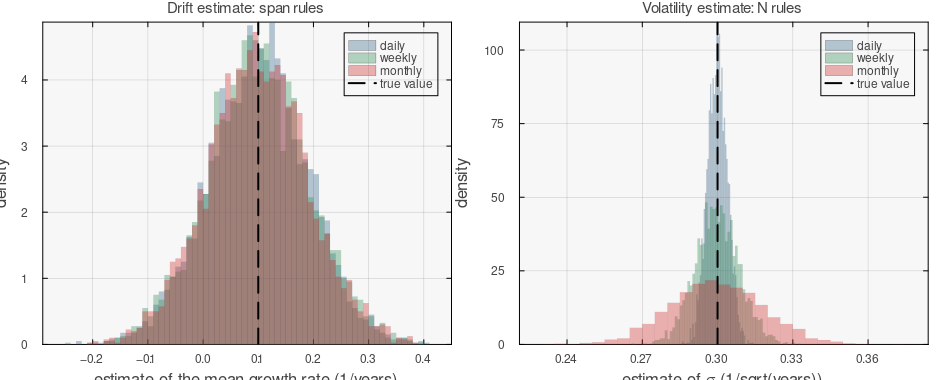

In [6]:
let
    p1 = plot(xlabel = "estimate of the mean growth rate (1/years)", ylabel = "density", title = "Drift estimate: span rules", titlefontsize = 10, legend = :topright)
    p2 = plot(xlabel = "estimate of σ (1/sqrt(years))", ylabel = "density", title = "Volatility estimate: N rules", titlefontsize = 10, legend = :topright)
    colors = (daily = :steelblue4, weekly = :seagreen4, monthly = :firebrick3)
    for name ∈ (:daily, :weekly, :monthly)
        res = sampling_results[name]
        histogram!(p1, res.ḡ_hat; bins = 60, normalize = :pdf, alpha = 0.35, color = colors[name], linewidth = 0, label = String(name))
        histogram!(p2, res.σ_hat; bins = 60, normalize = :pdf, alpha = 0.35, color = colors[name], linewidth = 0, label = String(name))
    end
    vline!(p1, [ḡ_true]; color = :black, linestyle = :dash, label = "true value")
    vline!(p2, [σ_true]; color = :black, linestyle = :dash, label = "true value")
    plot(p1, p2; layout = (1, 2), size = (940, 380))
end

___

## 2. How many years does a drift take?

Turn the span rule around. A 95% interval for $\bar g$ has half-width $1.96\,\sigma/\sqrt{T_{\text{span}}}$, so pinning the mean growth rate to within $\pm h$ per year needs
$$
T_{\text{span}}\geq\left(\frac{1.96\,\sigma}{h}\right)^{2}\ \text{years}.
$$
Let's tabulate the required span for a few precisions at $\sigma=0.30$, and compare with what the L4b example's descriptive regression interval implied, in the `span_table::DataFrame` variable:

In [7]:
span_table = let
    df = DataFrame(half_width_per_year = Float64[], years_required = Float64[])
    for h ∈ (0.10, 0.05, 0.02, 0.01)
        push!(df, (h, (1.96*σ_true/h)^2))
    end
    df
end
honest_half_width = 1.96*σ_true/sqrt(T_span)
println("With σ = $(σ_true) and $(T_span) years of data, the honest 95% half-width for ḡ is ± $(round(honest_half_width, digits = 3)) per year.")
println("The L4b example's regression intervals had half-widths between about ± 0.0007 and ± 0.013 per year (most near ± 0.002), tens of times too narrow.")
pretty_table(span_table; formatters = [fmt__printf("%.2f", [1,2])])

With σ = 0.3 and 11.0 years of data, the honest 95% half-width for ḡ is ± 0.177 per year.
The L4b example's regression interval had a half-width of about ± 0.001 to 0.005 per year, tens of times too narrow.
┌─────────────────────┬────────────────┐
│ half_width_per_year │ years_required │
│             Float64 │        Float64 │
├─────────────────────┼────────────────┤
│                0.10 │          34.57 │
│                0.05 │         138.30 │
│                0.02 │         864.36 │
│                0.01 │        3457.44 │
└─────────────────────┴────────────────┘


Eleven years of data leave the mean growth rate uncertain by about $\pm0.18$ per year, an interval wider than most plausible values of $\bar g$ itself; pinning it to $\pm0.01$ would take several thousand years of stationary data, which no market supplies. The regression interval in the L4b example, computed as if the log-price errors were independent, is tens of times too narrow, which is why the lecture called it descriptive. (The regression slope is a different estimator from the sample mean, and under Brownian errors it is slightly worse: its standard error is $\sqrt{6/5}\,\sigma/\sqrt{T_{\text{span}}}$, about 10% larger than the span rule, or roughly $\pm0.19$ per year here. Either way the honest interval is wide.) And this is the best case: real markets change regime, so even the honest interval is optimistic.

___

## 3. What drift uncertainty does to the target probability

The lecture's closed form for the probability that a scheduled long position clears a target $\rho_{\star}$ over a holding period $T$ with benchmark growth rate $g_{b}$ is
$$
\mathbb{P}(\rho_{T}>\rho_{\star})=1-\Phi\!\left(\frac{\ln(1+\rho_{\star})+g_{b}T-\bar g\,T}{\sigma\sqrt{T}}\right),
$$
and it takes $\bar g$ and $\sigma$ as known. They are not. Let's evaluate the curve of probability against target (the L4b example's plot) at the point estimates, and then at the ends of the honest 95% intervals for $\bar g$ (span rule) and for $\sigma$ ($\sigma/\sqrt{2N}$ with daily data), to see which uncertainty moves the decision:

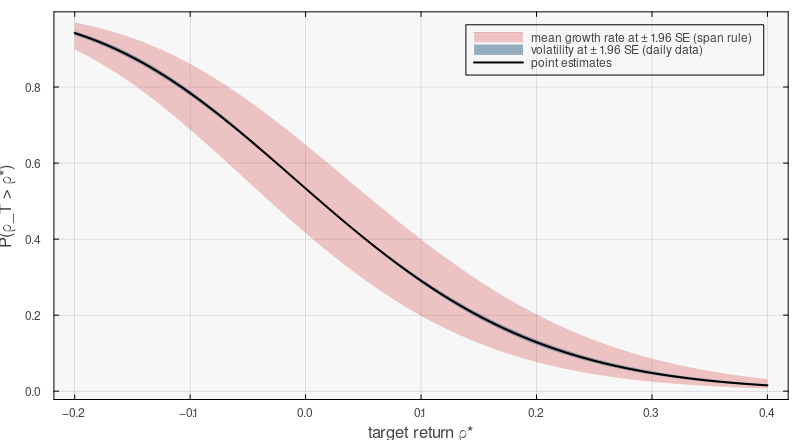

In [8]:
target_probability(ḡ::Real, σ::Real, T::Real, g_b::Real, ρ_star::Real) =
    1 - cdf(Normal(), (log(1 + ρ_star) + g_b*T - ḡ*T)/(σ*sqrt(T)))

T_hold = 63/252      # holding period (years), one trading quarter
g_b = 0.05           # benchmark growth rate (1/years)
N_daily = round(Int, T_span/sampling_schemes.daily)
se_ḡ = σ_true/sqrt(T_span)          # honest standard error of the drift estimate
se_σ = σ_true/sqrt(2*N_daily)       # standard error of the volatility estimate (daily data)

targets = range(-0.20, 0.40, length = 121)
p_point = [target_probability(ḡ_true, σ_true, T_hold, g_b, ρ) for ρ ∈ targets]
p_ḡ_low = [target_probability(ḡ_true - 1.96*se_ḡ, σ_true, T_hold, g_b, ρ) for ρ ∈ targets]
p_ḡ_high = [target_probability(ḡ_true + 1.96*se_ḡ, σ_true, T_hold, g_b, ρ) for ρ ∈ targets]
p_σ_low = [target_probability(ḡ_true, σ_true - 1.96*se_σ, T_hold, g_b, ρ) for ρ ∈ targets]
p_σ_high = [target_probability(ḡ_true, σ_true + 1.96*se_σ, T_hold, g_b, ρ) for ρ ∈ targets]

let
    plot(targets, p_ḡ_high; fillrange = p_ḡ_low, fillalpha = 0.25, color = :firebrick3, linewidth = 0,
        label = "mean growth rate at ± 1.96 SE (span rule)", xlabel = "target return ρ*", ylabel = "P(ρ_T > ρ*)", size = (800, 440), legend = :topright)
    plot!(targets, p_σ_high; fillrange = p_σ_low, fillalpha = 0.5, color = :steelblue4, linewidth = 0, label = "volatility at ± 1.96 SE (daily data)")
    plot!(targets, p_point; color = :black, label = "point estimates")
end

Let's read off the numbers at a few targets, in the `decision_table::DataFrame` variable:

In [9]:
decision_table = let
    df = DataFrame(target = Float64[], point = Float64[], ḡ_low = Float64[], ḡ_high = Float64[], σ_low = Float64[], σ_high = Float64[])
    for ρ ∈ (-0.10, 0.0, 0.05, 0.10, 0.20)
        push!(df, (ρ, target_probability(ḡ_true, σ_true, T_hold, g_b, ρ),
            target_probability(ḡ_true - 1.96*se_ḡ, σ_true, T_hold, g_b, ρ), target_probability(ḡ_true + 1.96*se_ḡ, σ_true, T_hold, g_b, ρ),
            target_probability(ḡ_true, σ_true - 1.96*se_σ, T_hold, g_b, ρ), target_probability(ḡ_true, σ_true + 1.96*se_σ, T_hold, g_b, ρ)))
    end
    df
end
pretty_table(decision_table; formatters = [fmt__printf("%.3f", [1,2,3,4,5,6])])

┌─────────┬─────────┬─────────┬─────────┬─────────┬─────────┐
│  target │   point │   ḡ_low │  ḡ_high │   σ_low │  σ_high │
│ Float64 │ Float64 │ Float64 │ Float64 │ Float64 │ Float64 │
├─────────┼─────────┼─────────┼─────────┼─────────┼─────────┤
│  -0.100 │   0.784 │   0.688 │   0.860 │   0.790 │   0.778 │
│   0.000 │   0.533 │   0.416 │   0.648 │   0.534 │   0.532 │
│   0.050 │   0.404 │   0.295 │   0.521 │   0.402 │   0.407 │
│   0.100 │   0.290 │   0.198 │   0.399 │   0.285 │   0.295 │
│   0.200 │   0.129 │   0.077 │   0.201 │   0.122 │   0.135 │
└─────────┴─────────┴─────────┴─────────┴─────────┴─────────┘


Over a one-quarter holding period the drift band moves the probability of a positive scaled NPV by about twelve percentage points in each direction (from roughly 0.42 to 0.65 around a point estimate of 0.53), while the volatility band moves it by a tenth of a point. The drift effect is only this small because $\bar g\,T$ is small over a quarter; over longer holding periods the drift term grows linearly with $T$ while the volatility term grows only with $\sqrt{T}$, so drift uncertainty dominates more and more. The practical reading is the one the lecture gave: a target probability computed from a fitted GBM is a model-based decision aid whose drift input is known only roughly, and any decision that hinges on the third decimal place of that probability is hinging on noise.

___

## Summary

This notebook explained why the drift is the hard parameter. The sample-mean estimate of the mean growth rate telescopes to the endpoints of the sample, so its precision is set by the calendar span alone, and honest error bars on the drift are wide enough to move a target probability by several points.

> __Key Takeaways:__
>
> - **The drift obeys a span rule:** The standard error of the mean growth rate is the volatility divided by the square root of the calendar span, independent of the sampling frequency, because the sample mean of growth rates depends only on the first and last prices.
> - **Volatility obeys an observation-count rule:** Its standard error shrinks with the square root of the number of growth-rate observations, so finer sampling helps volatility and does nothing for drift.
> - **Uncertainty should travel into the decision:** Propagating the honest drift interval through the closed-form target probability turns a single number into a band, and that band, not the point estimate, is what a trading decision should be judged against.

The next lecture estimates drifts for many assets at once, and the same span rule applies to every one of them.

___

## Disclaimer and Risks

This notebook is for instruction only. Sampling distributions here assume a constant-parameter GBM, which is the most favorable case; real markets add regime changes and heavy tails on top of the sampling error shown. This material is not investment or trading advice.

___